<a href="https://colab.research.google.com/github/vivek1905/Vivek_Foundations-of-AI-code-for-the-Final-Report/blob/main/Vivek_FAI_Code_for_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# IMPORT LIBRARIES
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import random

In [3]:
# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

In [4]:
# ENVIRONMENT SETUP
env = gym.make("FrozenLake-v1", is_slippery=True)

state_size = env.observation_space.n
action_size = env.action_space.n

print("State size:", state_size)
print("Action size:", action_size)

State size: 16
Action size: 4


In [5]:
# INITIALIZE Q-TABLE
q_table = np.zeros((state_size, action_size))

print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [6]:
# HYPERPARAMETERS

learning_rate = 0.1
discount_factor = 0.99

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 5000
max_steps = 100

In [7]:
# TRACKING METRICS
rewards = []
success_rate = []

# TRAINING LOOP
for episode in range(episodes):

    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):

        # Exploration vs Exploitation
        if np.random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)

        # Q-Learning Update
        q_table[state, action] = q_table[state, action] + learning_rate * (
            reward + discount_factor * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    # Update Exploration Rate
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    rewards.append(total_reward)
    success = 1 if total_reward > 0 else 0
    success_rate.append(total_reward)

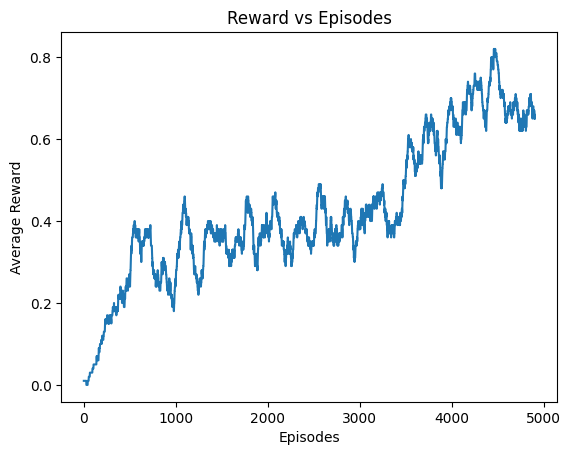

In [8]:
# PLOT RESULTS FOR REWARD CURVE
plt.figure()
plt.plot(np.convolve(rewards, np.ones(100)/100, mode='valid'))
plt.title("Reward vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.savefig("reward_plot.png")
plt.show()

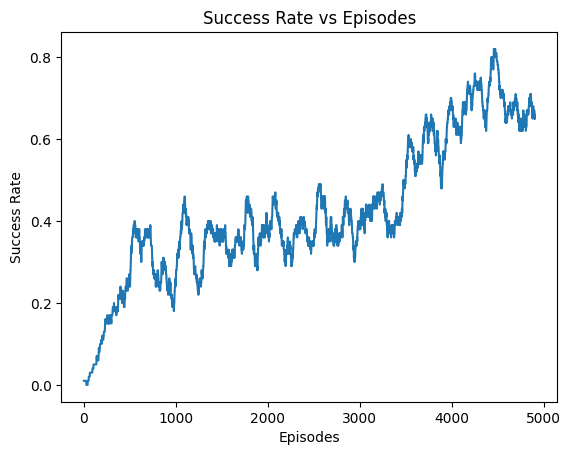

In [9]:
# PLOT RESULTS FOR SUCCESS RATE CURVE
plt.figure()
plt.plot(np.convolve(success_rate, np.ones(100)/100, mode='valid'))
plt.title("Success Rate vs Episodes")
plt.xlabel("Episodes")
plt.ylabel("Success Rate")
plt.savefig("success_plot.png")
plt.show()

In [10]:
# TEST TRAINED AGENT
test_episodes = 100
success = 0

for episode in range(test_episodes):

    state, _ = env.reset()

    for step in range(max_steps):

        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, _ = env.step(action)

        state = next_state

        if terminated or truncated:
            success += reward
            break

print("Success Rate:", success / test_episodes)
# Print average reward
print("Average Reward (last 100 episodes):", np.mean(rewards[-100:]))

Success Rate: 0.74
Average Reward (last 100 episodes): 0.65


In [11]:
# FINAL OUTPUTS
print("Final Q Table:")
print(q_table)

Final Q Table:
[[4.97266527e-01 4.63233933e-01 4.26251836e-01 4.65524718e-01]
 [4.12638639e-02 8.80255984e-02 1.33443760e-02 3.19296607e-01]
 [7.74436772e-02 2.40630155e-01 3.06047163e-02 3.01959893e-02]
 [2.74780484e-03 1.02107634e-01 2.34589497e-05 9.16490435e-05]
 [5.07703397e-01 4.28874775e-01 3.46026827e-01 4.41633332e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.19496793e-02 1.01447705e-01 3.06999799e-01 1.41112856e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [3.90744711e-01 2.70353139e-01 3.51867311e-01 5.39196425e-01]
 [2.72436117e-01 5.88002722e-01 2.87732784e-01 2.59082346e-01]
 [5.98456121e-01 2.08806158e-01 3.46934393e-01 2.38757944e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.36943243e-01 4.50014837e-01 7.57264612e-01 2.28613719e-01]
 [5.11758131e-01 8.79163791e-01 7.14430008e-01 6.91863914e-01]
 [0.00000000e+00 0.00000000e+00 0.000000

In [12]:
actions = ['←','↓','→','↑']
policy = np.argmax(q_table, axis=1)

grid = np.array([actions[a] for a in policy]).reshape(4,4)

print("\nLearned Policy:")
print(grid)


Learned Policy:
[['←' '↑' '↓' '↓']
 ['←' '←' '→' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]
